## Идеальный RAG pipeline

# Загрузка документов

## 1. Что делает document loader в RAG

Document loader – это "адаптер" между сырым источником данных (сайт, PDF, Notion, GitHub, YouTube и т.д.) и стандартным форматом `Document`, с которым дальше работает вся RAG-цепочка.

В LangChain все лоадеры реализуют общий интерфейс `BaseLoader` и, по сути, дают две операции

- `load()` – загрузить документы как есть;
- `loadAndSplit()` – загрузить и **сразу нарезать** на мелкие куски.

На уровне лоадера ты уже можешь контролировать качество сырья.

## 2. Какие ещё бывают лоадеры

LangChain делит лоадеры на **file loaders** и **web loaders**, плюс отдельные интеграции с облаком, продуктами и поиском.

**Основные категории**

[Document loaders - Docs by LangChain](https://docs.langchain.com/oss/python/integrations/document_loaders#by-category)

---

## 3. Оптимизация кода

### Текущий код


In [16]:
from langchain_community.document_loaders import WebBaseLoader
import os

os.environ["USER_AGENT"] = "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)"

loader = WebBaseLoader('https://mt-lab.su/')
docs = loader.load()

### Что делает код

- Подменяет `USER_AGENT`, чтобы сайт не думал, что ты бот.
- Через `WebBaseLoader` скачивает **одну HTML-страницу** `главную`.
- Превращает её в список `Document` с сырой HTML/текстовой начинкой.

### Основные недостатки подхода

1. **Только одна страница**
    
    Если у продукта 10 страниц документации, ты сейчас используешь только одну. Остальные разделы (`/blog`, `/docs`, `/fees`, `/terms`) остаются вне индекса.
    
2. **Нет обхода ссылок `/sitemap`’а**
    
    FAQ часто ссылается на более подробные статьи. Код их не трогает: нет рекурсивного обхода и нет загрузки по `sitemap.xml`.
    
3. **Много мусорного текста**
    
    `WebBaseLoader` без настроек забирает всё: меню, футер, баннеры, кнопки, копирайт. Это ухудшает эмбеддинги и поиск – модель начинает видеть "cookie / subscribe / terms" как часть контента.
    
4. **Нет работы с другими форматами**
    
    Если у проекта есть PDF-whitepaper, презентации, Airtable с тарифами, GitHub-репо с примерами – они не попадают в базу вообще.
    
5. **Нет стратегии по обновлению**
    
    Пока это "один раз дернули URL". Для реальной системы нужна регулярная загрузка, чтобы FAQ не устаревал.

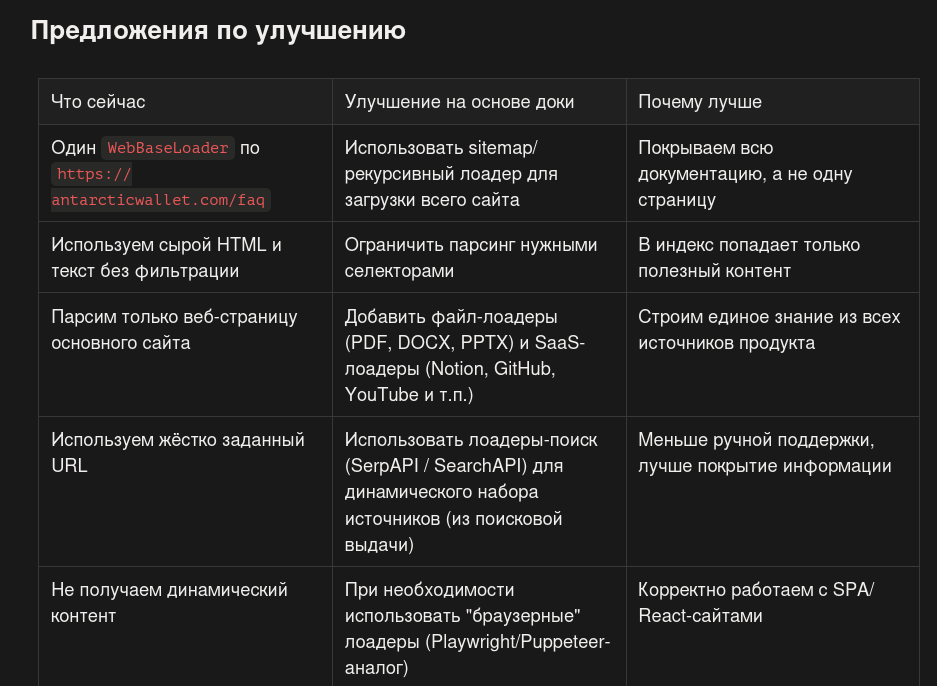



### Итоговый код

Для примера мы добавим мы улучшим только часть с тем, что мы парсим всего одну страницу. 

У большинства сайтов есть файл `sitemap.xml`.

Это официальный список всех страниц, которые сайт хочет индексировать (Google работает так же).

**SitemapLoader делает ровно то, что нужно для RAG:**

1. Скачивает `sitemap.xml`;
2. Достаёт из него все URL;
3. Загружает каждую страницу;
4. Возвращает список `Document` – по одному на страницу.

Таким образом: 

- Мы ничего не "придумываем"
- Не ходим по внешним ссылкам
- Получаем весь сайт целиком

https://mt-lab.su/ -- main

https://mt-lab.su/sitemap.xml | имеем три варианта (каталоги, продукты, о компании)

<sitemapindex>
<sitemap>
<loc>
https://mt-lab.su/sitemap-part-categories-index.xml --------> https://mt-lab.su/sitemap-part-categories-chunk-0.xml
</loc>
</sitemap>
<sitemap>
<loc>
https://mt-lab.su/sitemap-part-products-index.xml --------> https://mt-lab.su/sitemap-part-products-chunk-0.xml
</loc>
</sitemap>
<sitemap>
<loc>
https://mt-lab.su/sitemap-pages.xml --------> https://mt-lab.su/sitemap-pages.xml
</loc>
</sitemap>
</sitemapindex>


In [17]:
# Загрузка документов
import os
from langchain_community.document_loaders import SitemapLoader, RecursiveUrlLoader

os.environ["USER_AGENT"] = "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)"

ROOT_URL = "https://mt-lab.su/"
SITEMAP_URL = f"{ROOT_URL}/sitemap-part-categories-chunk-0.xml" # один из sitemap, который точно существует

# # 1) Загружаем все страницы из sitemap
# sitemap_loader = SitemapLoader(
#     web_path=SITEMAP_URL,
#     filter_urls=[ROOT_URL],  # на всякий случай ограничиваем доменом
# )

# sitemap_docs = sitemap_loader.load()

# only one page in sitemap
# Total documents: 18
# Total characters: 26043

# 2) Дополнительно рекурсивно обходим сайт от корня
recursive_loader = RecursiveUrlLoader(
    url=ROOT_URL,
    max_depth=1,          # глубину при желании можно увеличить
    prevent_outside=True  # не выходим за пределы домена
)
docs = recursive_loader.load()

# depth=2
# Total documents: 29
# Total characters: 2808801

# depth=3
# Total documents: 34
# Total characters: 3160292


# # 3) Объединяем всё в один список документов для RAG
# # docs = sitemap_docs + recursive_docs
# docs = recursive_docs

print(f"Total documents: {len(docs)}")
print(f"Total characters: {sum(len(doc.page_content) for doc in docs)}")

Total documents: 1
Total characters: 123335


# Разделение документов на кусочки (split)

## 1. Что делает text splitter в RAG

Text splitter – это слой между "сырыми" документами и эмбеддингами. Его задача:

- **разбить длинный текст на кусочки**, которые:
    - поместятся в контекст модели,
    - можно доставать по отдельности из векторного хранилища;
- **сохранить смысл и структуру** внутри каждого кусочка (не рвать предложения и логические блоки, где это возможно).

В LangChain рекомендуют в качестве дефолта `RecursiveCharacterTextSplitter`: он сначала пытается сохранить большие блоки (параграфы), если они не влезают – переходит на более мелкие единицы (предложения, слова).

## 2. Какие бывают стратегии разделения

В доке текстовые сплиттеры делят на три группы:

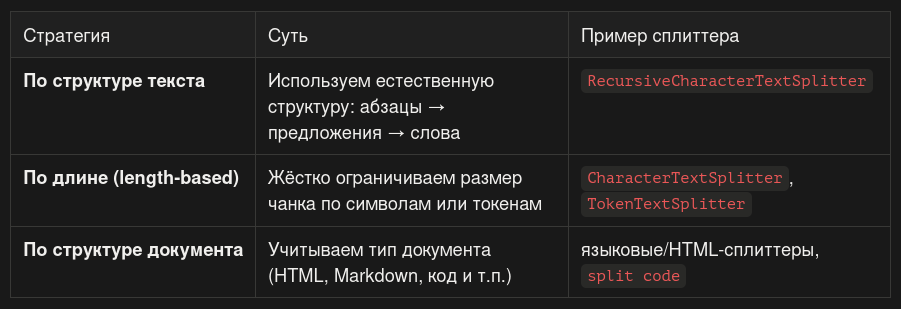

Коротко:

- **RecursiveCharacterTextSplitter** – хороший универсальный старт.
- **TokenTextSplitter** – когда важно строго уложиться в лимит токенов модели.
- **Языковые/HTML/Markdown-сплиттеры** – когда важно не рвать структуру документа (код, HTML, Markdown и т.п.).

## 3. Оптимизация кода

Текущий код

In [4]:
# Разделение документов на кусочки (split)
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
)
splits = text_splitter.split_documents(docs)

### Что делает код

- Использует `RecursiveCharacterTextSplitter` с:
    - `chunk_size=1000` символов,
    - `chunk_overlap=200` символов перекрытия.
- Сплиттер идёт по иерархии разделителей: параграфы → предложения → слова, пока не уложится в заданный размер.

### Основные недостатки подхода

1. **Ориентир на символы, а не токены**
    
    Модель ограничена токенами, а не символами. 1000 символов в русском/HTML могут давать сильно разное число токенов. В доке отдельно подчёркивают, что для RAG удобно считать именно токены.
    
2. **Один и тот же сплиттер для любого типа текста**
    
    Сейчас документы режутся как обычный "плоский текст", хотя по факту это HTML-страницы со своей структурой (заголовки, секции, списки, блоки FAQ). Из-за этого один логический блок может быть разрезан посередине, а разные части страницы – склеены в один чанк.

    В LangChain есть структурные режимы сплиттинга, например `RecursiveCharacterTextSplitter.from_language(Language.HTML)`, которые знают, где в HTML находятся естественные границы (заголовки, блоки контента) и стараются резать текст именно по ним. В результате каждый чанк соответствует законченному разделу страницы, что напрямую улучшает качество поиска и ответов в RAG.

3. **Параметры выбраны "на глаз"**
    
    `chunk_size=1000` / `chunk_overlap=200` никак не привязаны:
    
    - к контексту конкретной модели (4k/8k/16k токенов),
    - к типу задач (QA vs суммаризация).
        
        В документации советуют начинать с разумного дефолта и дальше подстраивать под приложение.
        

### Предложения по улучшению

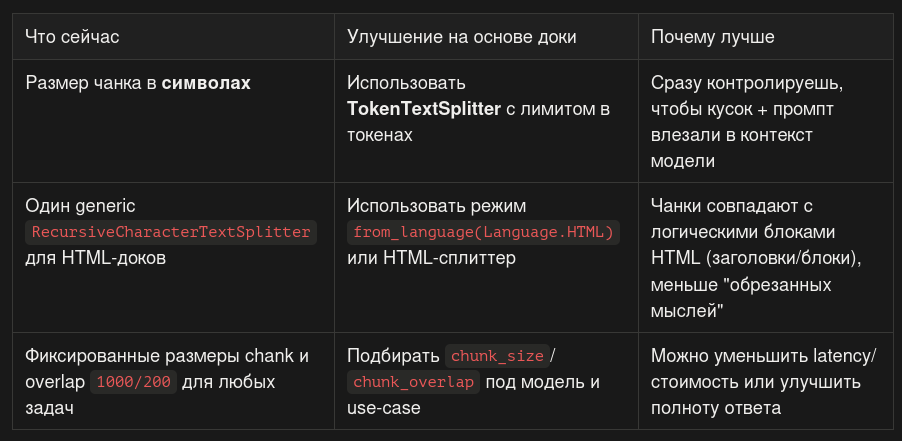



### Итоговый код

**Вариант 1. HTML-ориентированный split через язык**

Этот вариант лучше подходит как раз для страниц, которые ты грузишь с сайта (HTML):

In [18]:
from langchain_text_splitters import RecursiveCharacterTextSplitter, Language

text_splitter = RecursiveCharacterTextSplitter.from_language(
    language=Language.HTML,   # учитываем структуру HTML
    chunk_size=1200,          # немного больше, т.к. структура сохраняется лучше
    chunk_overlap=200,
)

splits = text_splitter.split_documents(docs)

Что меняется:

- сплиттер использует преднастроенные разделители для HTML (`Language.HTML`), а не общий список;
- чанки будут ближе к реальным блокам страницы (секции, div’ы, заголовки).

**Вариант 2. Токен-базовый split под лимиты модели**

In [7]:
from langchain_text_splitters import TokenTextSplitter

token_splitter = TokenTextSplitter(
    chunk_size=256,   # в токенах
    chunk_overlap=32, # тоже в токенах
)

splits = token_splitter.split_documents(docs)

Это хороший шаг для продакшена:

> "Сначала мы делим логично (HTML/структура), а дальше – контролируем токены, чтобы точно не вылетать из контекста модели".
> 

# Создание embeddings

## 1. Что такое embeddings в RAG

Embeddings – это способ превратить текст в числовой вектор так, чтобы **похожие по смыслу тексты имели похожие вектора**.

Именно embeddings позволяют RAG-системе делать **семантический поиск**, а не искать совпадения слов.

В RAG embeddings используются в двух местах:

1. **При индексации** – когда мы превращаем документы (чанки) в вектора и кладём их в vector store.
2. **При запросе пользователя** – когда вопрос тоже превращается в вектор и сравнивается с документами.

Одна и та же embedding-модель должна использоваться и для документов, и для запросов.

## 2. Какие бывают embedding-модели

В LangChain embedding-модели – это отдельные интеграции, каждая из которых реализует единый интерфейс `Embeddings`.

По сути, у любой модели есть два метода:

- `embed_documents()` – для документов;
- `embed_query()` – для пользовательского запроса.

### Основные категории embedding-моделей

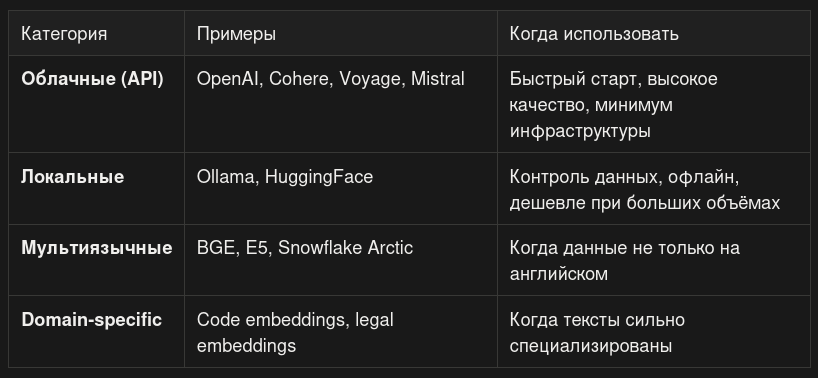

В документации LangChain прямо подчёркивается: выбор embedding-модели – один из самых важных факторов качества RAG.

## 3. Оптимизация кода

### Текущий код

In [ ]:
# Создаём embeddings
from langchain_ollama import OllamaEmbeddings

EMBEDDING_MODEL = "hf.co/Casual-Autopsy/snowflake-arctic-embed-l-v2.0-gguf:Q4_K_M"
OLLAMA_EMBEDDING_BASE_URL = "http://127.0.0.1:11434"

embeddings = OllamaEmbeddings(
    model=EMBEDDING_MODEL,
    base_url=OLLAMA_EMBEDDING_BASE_URL,
)

req = embeddings.embed_query("Привет, как дела?")  # пример запроса для получения эмбеддингов
print(req)

[-0.010314466, -0.0068332716, -0.04557045, -0.050392352, -0.026100751, 0.032460395, 0.049847193, 0.058093097, -0.02185408, -0.020544926, 0.00034323902, 0.023748543, 0.006529608, 0.018157274, 0.017760955, 0.03421844, 0.06474504, -0.017354237, -0.021317316, -0.009938152, -0.010055061, 0.09630137, 0.007446229, -0.032199826, 0.08336375, -0.0048895204, -0.029667145, -0.015686916, -0.008830524, -0.059846133, -0.0061580725, 0.03231899, 0.06828636, -0.077467285, 0.02209612, -0.00026299342, 0.04112918, -0.050867505, -0.11067985, 0.03898202, -0.0144107565, 0.0036066948, -0.03863445, -0.038605984, 0.0042554447, -0.002831468, -0.03366079, -0.076285355, 0.0006399257, -0.002178669, -0.033787183, 0.0144850025, -0.0055944785, 0.0057398477, -0.029769607, 0.036479216, -0.0018650802, -0.0552541, -0.023556184, -0.019984042, 0.056674086, 0.026509663, 0.029147388, -0.025920251, -0.08010405, 0.059822246, 0.0032306148, -0.0010338476, -0.018334093, -0.024590192, -0.05905939, 0.008276605, 0.026122814, 0.0188892

### Что делает код

- Использует **локальную embedding-модель** через Ollama.
- Модель `snowflake-arctic-embed-l` – современная embedding-модель общего назначения.
- Все embeddings считаются **локально**, без отправки данных во внешние API.

Это хороший продакшн-ориентированный старт, но есть нюансы.

### Основные недостатки подхода

1. **Модель выбрана без привязки к языку данных**
    
    Модель Arctic – сильная, но изначально ориентирована на английский. Если в документах много русского текста, качество семантического поиска может быть хуже, чем у специализированных мультиязычных моделей.
    
2. **Не учитывается размер эмбеддинга**
    
    Разные модели возвращают вектора разной размерности (384, 768, 1024, 1536+).
    
    Чем больше размер – тем:
    
    - больше память vector store;
    - медленнее поиск.
        
    В коде это никак не учитывается и выбирается "самая большая" модель по умолчанию.

3. **Нет стратегии под use-case**
    
    Embedding-модель выбирается одинаково для:
    
    - FAQ,
    - длинных документов,
    - коротких ответов.
        
    В доках LangChain рекомендуют подбирать модель под задачу: QA, поиск, кластеризация, code-search и т.д.
        
4. **Нет fallback-варианта**
    
    Если Ollama недоступна или модель не прогрелась – пайплайн падает. В продакшене часто держат облачную модель как запасной вариант.
    

### Предложения по улучшению

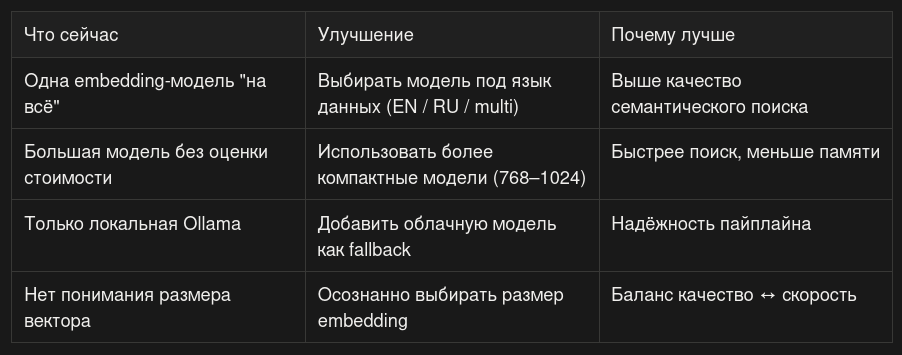

### Итоговый код

В качестве улучшения мы просто поменяем модель `snowflake-arctic-embed-l` на модель от российского разработчика:

https://huggingface.co/ai-forever/ru-en-RoSBERTa

In [19]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.embeddings import Embeddings

# Базовая модель
base_embeddings = HuggingFaceEmbeddings(
    model_name="ai-forever/ru-en-RoSBERTa"
)

class PrefixedEmbeddings(Embeddings):
    def __init__(self, base, query_prefix="", doc_prefix=""):
        self.base = base
        self.query_prefix = query_prefix
        self.doc_prefix = doc_prefix

    def embed_documents(self, texts):
        texts_prefixed = [self.doc_prefix + t for t in texts]
        return self.base.embed_documents(texts_prefixed)

    def embed_query(self, text):
        return self.base.embed_query(self.query_prefix + text)

embeddings = PrefixedEmbeddings(
    base_embeddings,
    query_prefix="search_query: ",
    doc_prefix="search_document: ",
)

print(embeddings.embed_query("Привет, как дела?"))

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 1569.18it/s]
RobertaModel LOAD REPORT from: ai-forever/ru-en-RoSBERTa
Key                 | Status  | 
--------------------+---------+-
pooler.dense.weight | MISSING | 
pooler.dense.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[0.009199555963277817, -0.010738550685346127, -0.0012247703270986676, 0.010181044228374958, 0.017092565074563026, 0.035003598779439926, -0.019326118752360344, -0.007804022170603275, -0.00691161910071969, -0.06191858649253845, 0.006163228768855333, -0.03864208981394768, -0.03135858103632927, 0.017288440838456154, 0.020299552008509636, -0.006605944130569696, 0.03888862952589989, -0.027151623740792274, -0.008253038860857487, 0.010795585811138153, 0.0035497730132192373, 0.013414313085377216, 0.011716409586369991, 0.020851418375968933, -0.03943091630935669, 0.03055892512202263, -0.023713458329439163, 0.01566658541560173, 0.00541088217869401, -0.045147188007831573, -0.0008733912254683673, 0.008185787126421928, 0.007946779951453209, 0.010393242351710796, -0.05370964854955673, -0.018061308190226555, -0.013933714479207993, -0.02774936333298683, -0.03351343795657158, -0.05034078657627106, -0.014550563879311085, -0.04316791519522667, -0.019976818934082985, -0.0038029749412089586, -0.0174538921564

Почему так лучше:

- одинаково хорошо работает с RU и EN;
- меньше "потерь смысла" при смешанных языках.
- Зачем добавили класс `PrefixedEmbeddings`
    
    **Проблема:**
    
    Embedding-модель получает документы и пользовательские запросы в одинаковом виде – просто как текст. Для неё нет разницы, где база знаний, а где вопрос. При этом многие современные embedding-модели (в том числе RoSBERTa-подобные) обучались с явным разделением типов текста: *документы* и *поисковые запросы* подавались с разными текстовыми префиксами. Без этого модель работает, но использует свой потенциал не полностью.
    
    **Решение:**
    
    Мы добавили класс `PrefixedEmbeddings`, который автоматически:
    
    - добавляет префикс `search_document:` ко всем документам;
    - добавляет префикс `search_query:` к запросам пользователя.
    
    Таким образом модель начинает понимать **роль текста**, а не только его содержание. Это повышает качество семантического поиска и релевантность ответов в RAG, при этом весь остальной пайплайн LangChain (vector store, retriever, цепочки) остаётся без изменений.

- Ошибка `Some weights of RobertaModel were not initialized from the model checkpoint at ai-forever/ru-en-RoSBERTa and are newly initialized`
    
    Это предупреждение означает, что в чекпоинте модели `ai-forever/ru-en-RoSBERTa` отсутствуют веса верхнего `pooler`-слоя, поэтому библиотека `transformers` инициализирует его случайно и сообщает об этом. `Pooler` используется в задачах классификации или предсказаний "на уровне всего текста", но при создании эмбеддингов в RAG он, как правило, не участвует – векторы берутся из скрытых слоёв модели (например, через усреднение токенов или CLS-вектор). Поэтому дообучать модель в нашем случае не требуется, и это предупреждение не влияет на качество семантического поиска или работу RAG-системы.

# Векторные хранилища

## 1. Что делает vector store в RAG

Vector store – это слой, который отвечает за **хранение эмбеддингов** и **поиск по смыслу**.

Именно здесь происходит ключевая операция RAG: поиск фрагментов текста, которые **семантически близки** к вопросу пользователя.

Проще говоря:

- документы → превращаются в embeddings;
- embeddings → сохраняются в vector store;
- вопрос пользователя → тоже превращается в embedding;
- vector store ищет **ближайшие вектора** и возвращает связанные документы.

В LangChain все vector store реализуют единый интерфейс, поэтому почти любой backend можно заменить без переписывания RAG-цепочки.

## 2. Какие бывают vector store

LangChain поддерживает десятки векторных хранилищ – от локальных до облачных и распределённых.

**Основные категории**

[Vector stores – Docs by LangChain](https://docs.langchain.com/oss/javascript/integrations/vectorstores?utm_source=chatgpt.com)

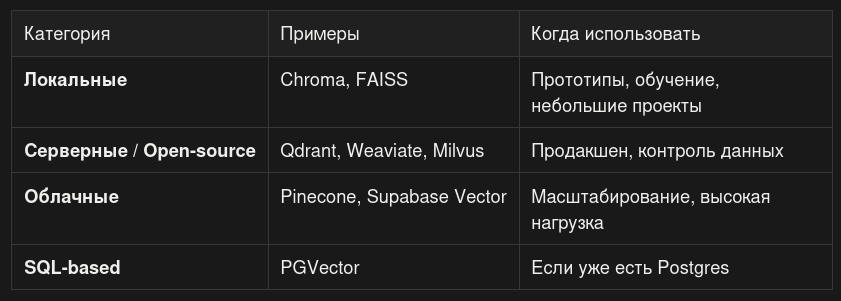

vector store – это инфраструктурный выбор, а не часть бизнес-логики. Его можно заменить, если правильно выстроен интерфейс.

---

## 3. Оптимизация кода

### Текущий код

In [ ]:
from langchain_community.vectorstores import Chroma

persist_directory = "./chroma_db"

vectorstore = Chroma.from_documents(
    documents=splits,
    embedding=embeddings,
    persist_directory=persist_directory,
)

### Что делает код

- Берёт готовые чанки `splits`;
- Считает для них embeddings;
- Создаёт локальное vector store **Chroma**;
- Сохраняет индекс на диск в `./chroma_intro_db`.

### Основные недостатки подхода

1. **Индекс пересобирается при каждом запуске**
    
    `Chroma.from_documents(...)` каждый раз:
    
    - заново считает embeddings;
    - пересоздаёт коллекцию.
    
    При росте данных это становится:
    
    - медленно,
    - дорого,
    - неудобно для обновлений.

2. **Нет инкрементального обновления**
    
    Если добавился один новый документ:
    
    - приходится пересобирать весь индекс,
    - нельзя просто "добавить ещё".
3. **Не используются метаданные**
    
    Без метаданных нельзя:
    
    - фильтровать документы по источнику (`faq`, `blog`, `terms`);
    - ограничивать поиск по типу или дате;
    - управлять релевантностью.
4. **Chroma выбран без объяснения альтернатив**
    
    Chroma отлично подходит для старта, но:
    
    - не всегда оптимален для больших объёмов;
    - не масштабируется горизонтально;
    - не всегда подходит для продакшена.

Предложения по улучшению

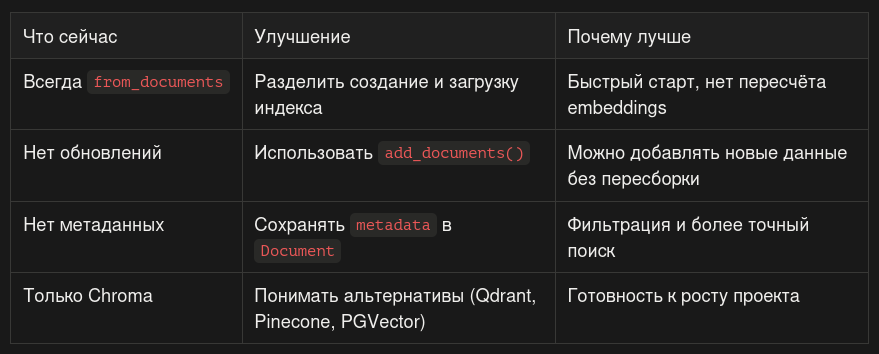

### Итоговый код

Для примера улучшим **только один момент** – избавимся от пересоздания индекса при каждом запуске.

In [20]:
from pathlib import Path
from langchain_community.vectorstores import Chroma

persist_directory = "./chroma_db_mt_lab"

if Path(persist_directory).exists():
    # Индекс уже есть – просто загружаем
    vectorstore = Chroma(
        embedding_function=embeddings,
        persist_directory=persist_directory,
    )
else:
    # Первый запуск – создаём индекс
    vectorstore = Chroma.from_documents(
        documents=splits,
        embedding=embeddings,
        persist_directory=persist_directory,
    )

Теперь:

- embeddings считаются **один раз**;
- последующие запуски поднимают готовый индекс;
- код остаётся простым и понятным;
- появляется возможность дальше:
    - добавлять документы,
    - удалять их,
    - мигрировать на другой vector store.